best for dieclectric (n=4 - chi =0.5/psi=134)

best for AU (chi=-5, psi=140)

best for effective polarization (psi=143, chi =9.5)

In [1]:
from MieSppForce.simulation import SimulationConfig, SweepRunner2D, SweepRunner
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()

config_au = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=(297/2)*ureg.nanometer,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(25),  
    chi = np.deg2rad(-5),
    psi = np.deg2rad(140),
    show_warnings=False,
    initial_field_type='two_beam',
)

config_sio2 = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=(297/2)*ureg.nanometer,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(25),  
    chi = np.deg2rad(0.5),
    psi = np.deg2rad(134),
    show_warnings=False,
    initial_field_type='two_beam',
    substrate=np.sqrt(1.45+0.01*1j)
)

config_effective = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=(297/2)*ureg.nanometer,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(25),  
    chi = np.deg2rad(9.5),
    psi = np.deg2rad(143),
    show_warnings=False,
    initial_field_type='two_beam',
    effective_dipoles_in_air=True
)

R_arr_sort = np.linspace(120,155,400) * ureg.nm


/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
res_au, _,_=  SweepRunner(config_au, 'R',R_arr_sort, True, False, True, False).run()

res_si02, _,_=  SweepRunner(config_sio2, 'R',R_arr_sort, True, False, True, False).run()

res_effective_air, _,_=  SweepRunner(config_effective, 'R',R_arr_sort, True, False, True, False).run()

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

In [3]:
base_config_free_space = SimulationConfig(
    wl = config_au.wl,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(0),
    psi = 0,
    chi = 0,
    show_warnings=False,
    substrate = 'Air',
    initial_field_type='two_beam',
)

sweep_res_free_space2, _, _ = SweepRunner(base_config_free_space, 'R', R_arr_sort, True, False, True, False).run()

F0arr = np.abs(sweep_res_free_space2['Fz'].magnitude)

  0%|          | 0/400 [00:00<?, ?it/s]

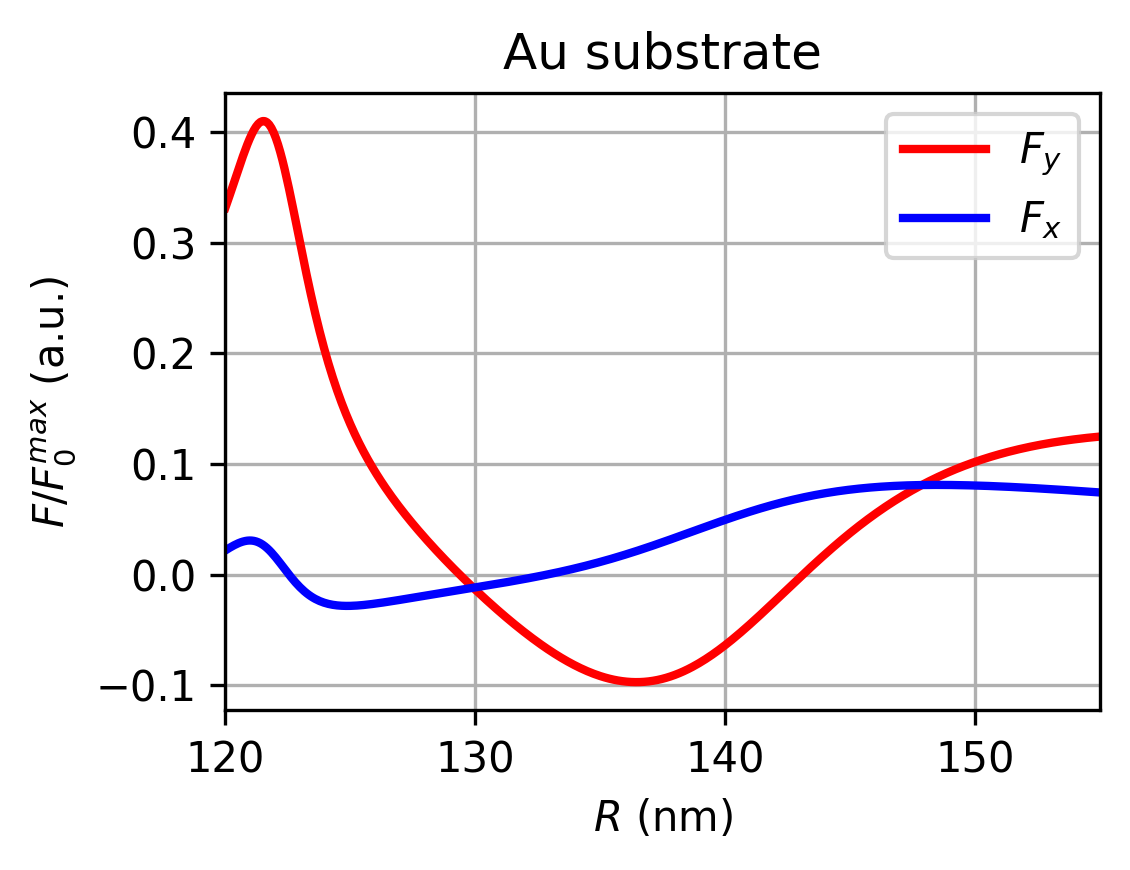

In [24]:
import matplotlib.pyplot as plt

F0 = np.max(F0arr)

plt.figure(figsize=(4, 3), dpi=300)
plt.plot(res_au.R.magnitude, res_au.Fy.magnitude/F0, label='$F_y$', lw=2, c='red' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,1]/F0, label='$F_x$ (Numerical)', lw=2, c='blue', ls='--' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,2]/F0, label='$F_y$ (Numerical)', lw=2, c='red', ls='--' )

plt.plot(res_au.R.magnitude, res_au.Fx.magnitude/F0, label='$F_x$', lw=2, c='blue')
plt.legend()
plt.xlabel('$R$ (nm)')
plt.ylabel('$F/F_0^{max}$ (a.u.)')
plt.grid()
plt.xlim(res_au.R.min().magnitude, res_au.R.max().magnitude)

plt.title('Au substrate')
plt.tight_layout()
plt.savefig('article_plots/Fx_Fy_vs_R_two_beam_sorting_au.png', dpi=300)
plt.show()

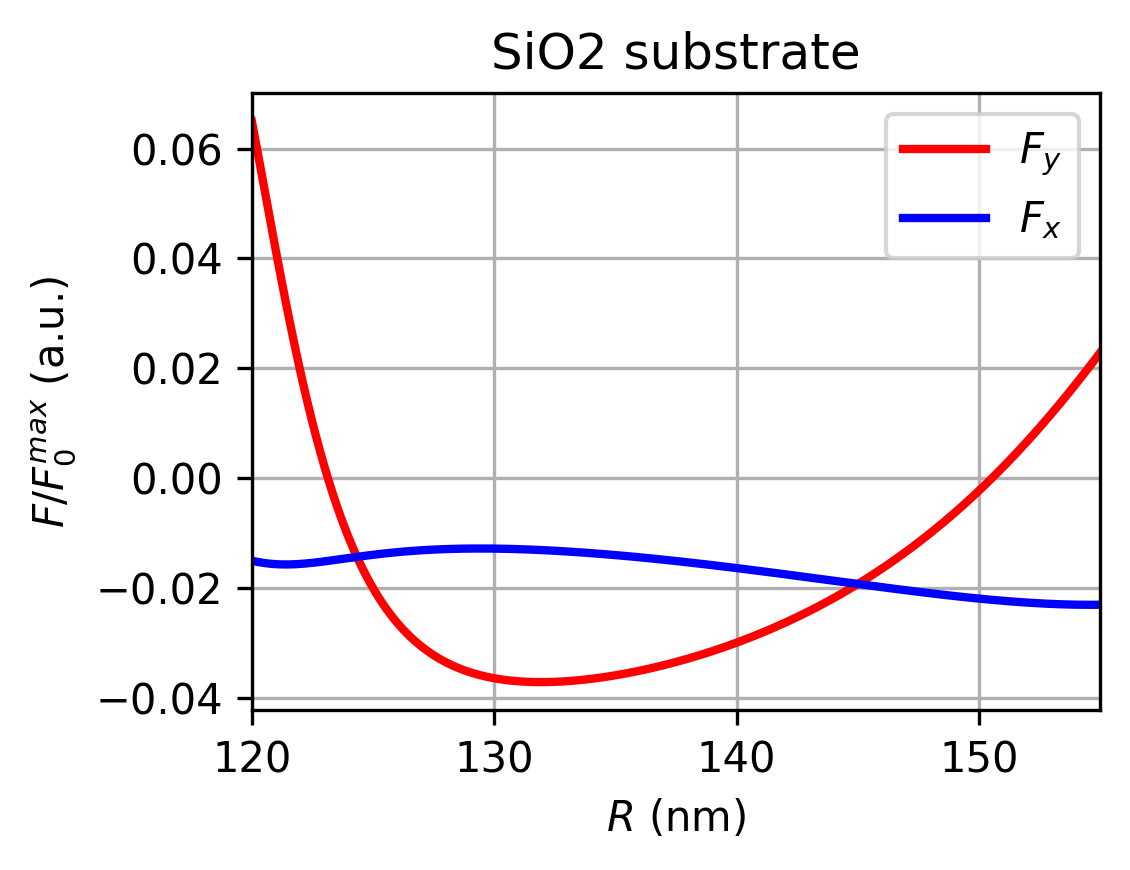

In [25]:
import matplotlib.pyplot as plt

F0 = np.max(F0arr)

plt.figure(figsize=(4, 3), dpi=300)
plt.plot(res_si02.R.magnitude, res_si02.Fy.magnitude/F0, label='$F_y$', lw=2, c='red' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,1]/F0, label='$F_x$ (Numerical)', lw=2, c='blue', ls='--' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,2]/F0, label='$F_y$ (Numerical)', lw=2, c='red', ls='--' )

plt.plot(res_si02.R.magnitude, res_si02.Fx.magnitude/F0, label='$F_x$', lw=2, c='blue')
plt.legend()
plt.xlabel('$R$ (nm)')
plt.ylabel('$F/F_0^{max}$ (a.u.)')
plt.grid()
plt.xlim(res_si02.R.min().magnitude, res_si02.R.max().magnitude)
plt.title('SiO2 substrate')
plt.tight_layout()
plt.savefig('article_plots/Fx_Fy_vs_R_two_beam_sorting_sio2.png', dpi=300)
plt.show()

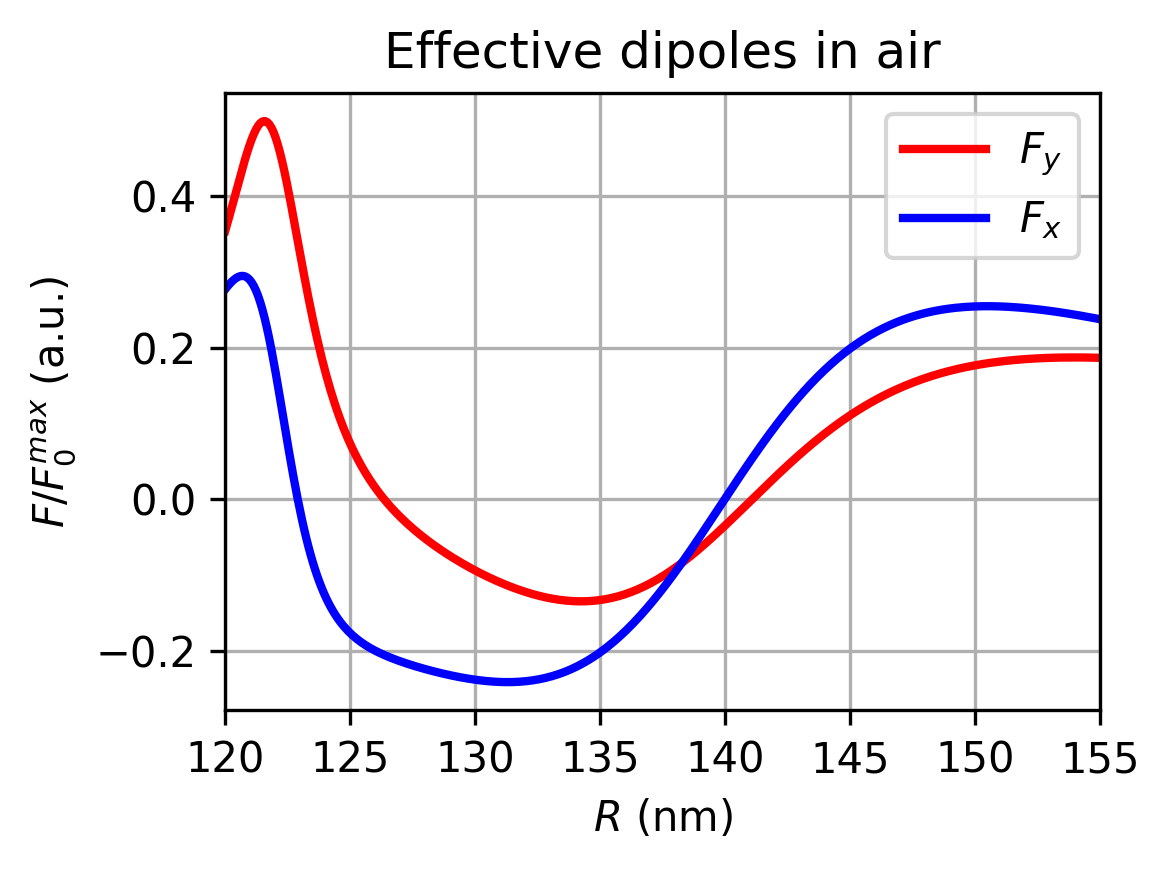

In [26]:
import matplotlib.pyplot as plt

F0 = np.max(F0arr)

plt.figure(figsize=(4, 3), dpi=300)
plt.plot(res_effective_air.R.magnitude, res_effective_air.Fy.magnitude/F0, label='$F_y$', lw=2, c='red' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,1]/F0, label='$F_x$ (Numerical)', lw=2, c='blue', ls='--' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,2]/F0, label='$F_y$ (Numerical)', lw=2, c='red', ls='--' )

plt.plot(res_effective_air.R.magnitude, res_effective_air.Fx.magnitude/F0, label='$F_x$', lw=2, c='blue')
plt.legend()
plt.xlabel('$R$ (nm)')
plt.ylabel('$F/F_0^{max}$ (a.u.)')
plt.grid()
plt.xlim(res_effective_air.R.min().magnitude, res_effective_air.R.max().magnitude)
plt.title('Effective dipoles in air')
plt.tight_layout()
plt.savefig('article_plots/Fx_Fy_vs_R_two_beam_sorting_effective_air.png', dpi=300)
plt.show()

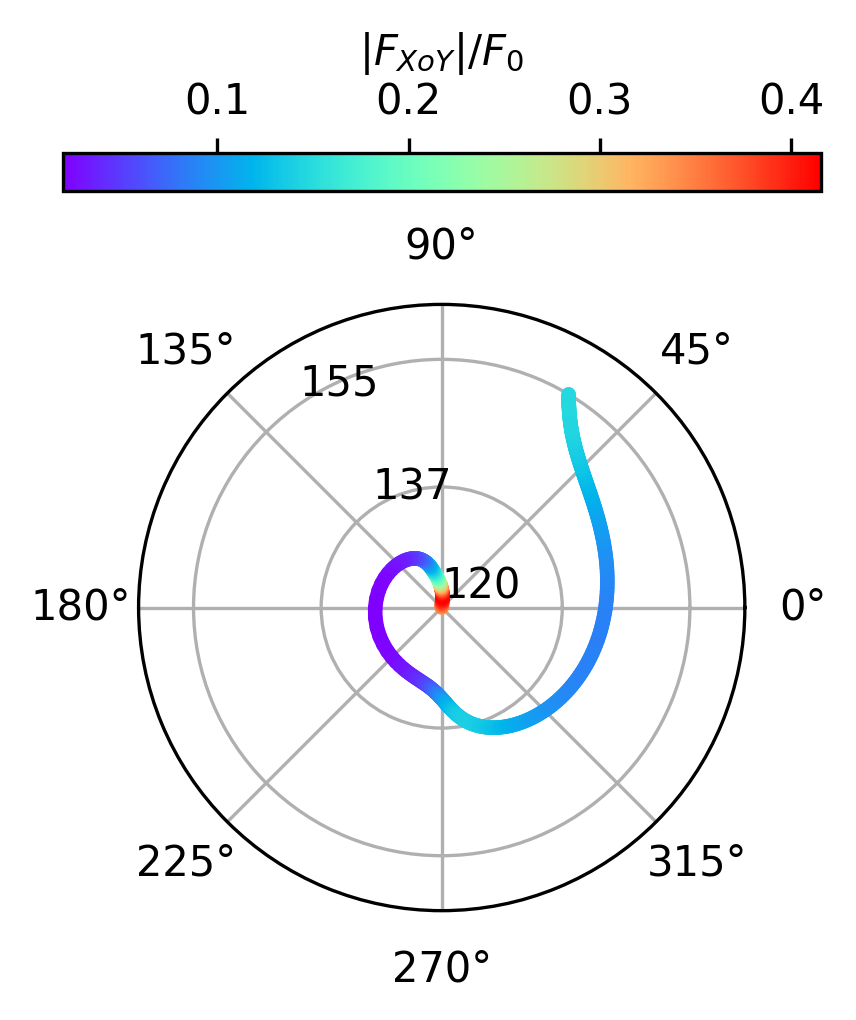

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

Fx = res_au.Fx.magnitude
Fy = res_au.Fy.magnitude
R  = res_au.R.magnitude

phi = np.arctan2(Fy, Fx)

Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr

points = np.array([phi, R]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=Fabs.min(), vmax=Fabs.max())

lc = LineCollection(
    segments,
    cmap="rainbow",
    norm=norm,
    linewidth=3.5,
    alpha=1.0,
    antialiased=True,
    capstyle="round",
    joinstyle="round"
)

lc.set_array(Fabs[:-1])


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

ax.set_ylim(R.min(), R.max() * 1.05)
ax.set_yticks(np.linspace(R.min(), R.max(), 3, dtype=int))

# ax.set_ylabel(r"$R$ (nm)", labelpad=25)

ax.set_rlabel_position(125)

# --- colorbar now shows force magnitude ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation="horizontal",
    location="top",
    fraction=0.05,
    pad=0.15
)

cbar.set_label(r"$|F_{XoY}|/F_0$")

plt.tight_layout()
# plt.title('Au substrate')
plt.savefig("article_plots/phi_R_forcecolor_polar_au_subs.png", dpi=300)
# plt.savefig("article_plots/phi_R_forcecolor_polar_dielect_subs.png", dpi=300)
plt.show()

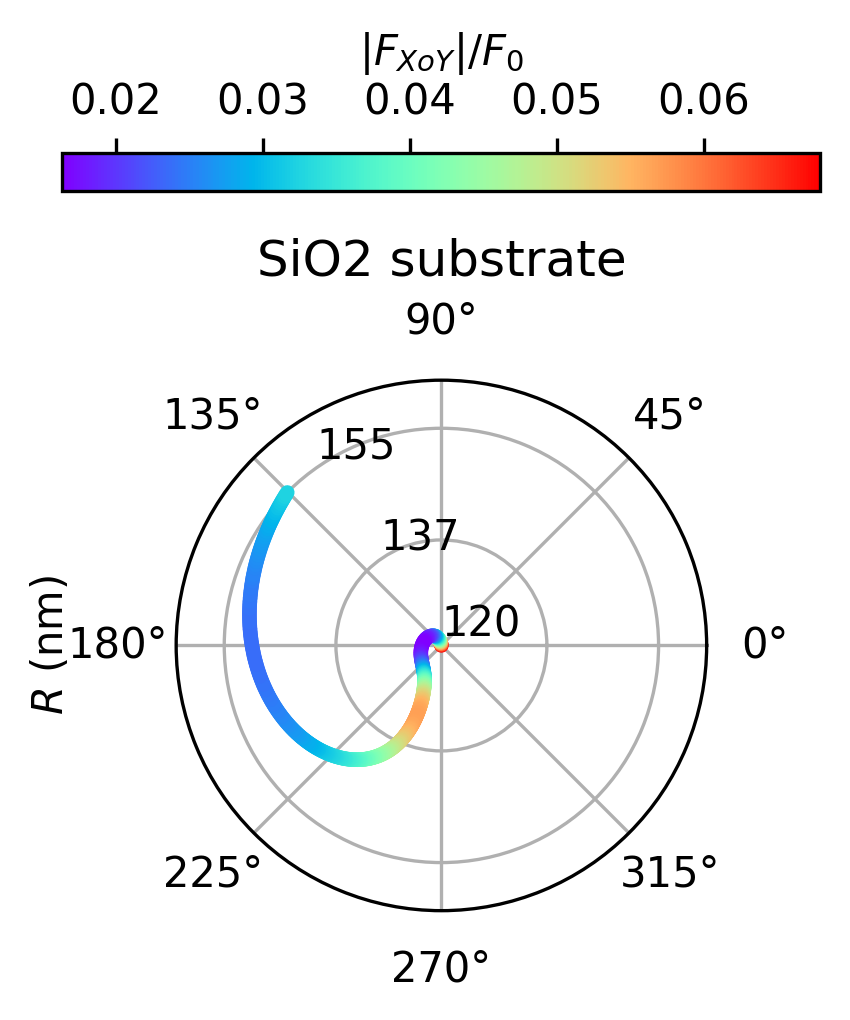

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

Fx = res_si02.Fx.magnitude
Fy = res_si02.Fy.magnitude
R  = res_si02.R.magnitude

phi = np.arctan2(Fy, Fx)

Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr

points = np.array([phi, R]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=Fabs.min(), vmax=Fabs.max())

lc = LineCollection(
    segments,
    cmap="rainbow",
    norm=norm,
    linewidth=3.5,
    alpha=1.0,
    antialiased=True,
    capstyle="round",
    joinstyle="round"
)

lc.set_array(Fabs[:-1])


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

ax.set_ylim(R.min(), R.max() * 1.05)
ax.set_yticks(np.linspace(R.min(), R.max(), 3, dtype=int))

ax.set_ylabel(r"$R$ (nm)", labelpad=25)

ax.set_rlabel_position(125)

# --- colorbar now shows force magnitude ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation="horizontal",
    location="top",
    fraction=0.05,
    pad=0.25
)

cbar.set_label(r"$|F_{XoY}|/F_0$")

plt.title('SiO2 substrate')

plt.tight_layout()
plt.savefig("article_plots/phi_R_forcecolor_polar_si02_subs.png", dpi=300)
# plt.savefig("article_plots/phi_R_forcecolor_polar_dielect_subs.png", dpi=300)
plt.show()

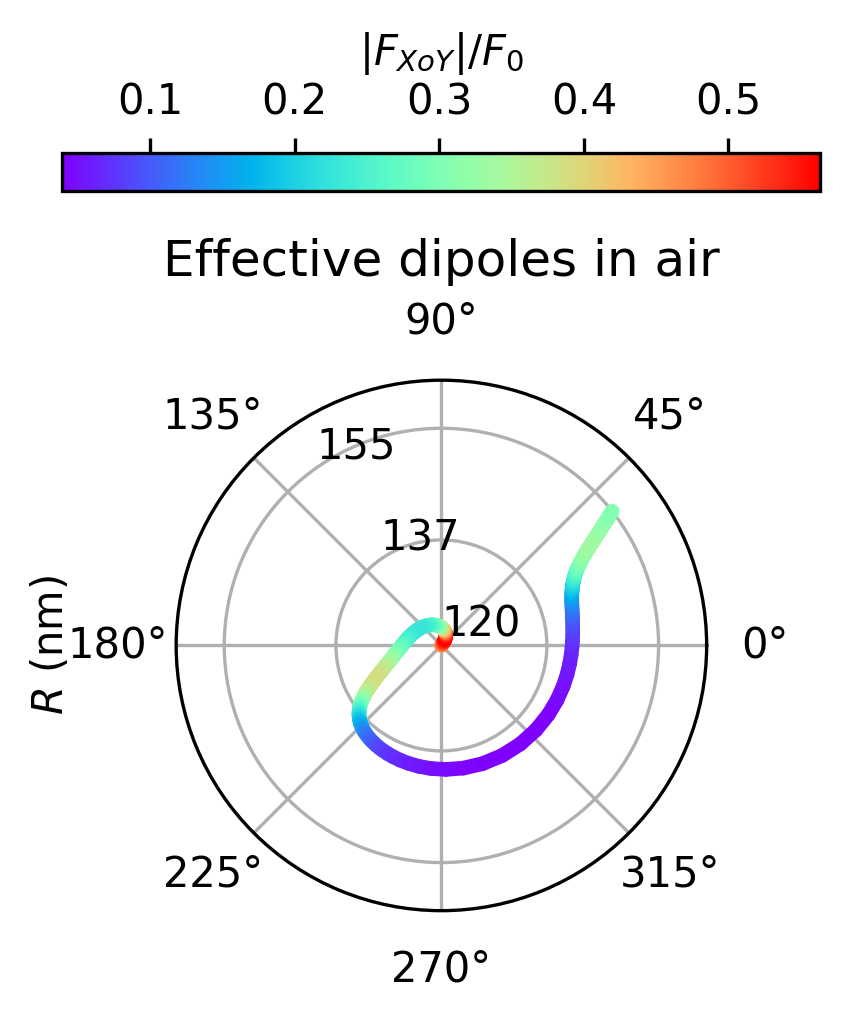

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

Fx = res_effective_air.Fx.magnitude
Fy = res_effective_air.Fy.magnitude
R  = res_effective_air.R.magnitude

phi = np.arctan2(Fy, Fx)

Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr

points = np.array([phi, R]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=Fabs.min(), vmax=Fabs.max())

lc = LineCollection(
    segments,
    cmap="rainbow",
    norm=norm,
    linewidth=3.5,
    alpha=1.0,
    antialiased=True,
    capstyle="round",
    joinstyle="round"
)

lc.set_array(Fabs[:-1])


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

ax.set_ylim(R.min(), R.max() * 1.05)
ax.set_yticks(np.linspace(R.min(), R.max(), 3, dtype=int))

ax.set_ylabel(r"$R$ (nm)", labelpad=25)

ax.set_rlabel_position(125)

# --- colorbar now shows force magnitude ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation="horizontal",
    location="top",
    fraction=0.05,
    pad=0.25
)

cbar.set_label(r"$|F_{XoY}|/F_0$")

plt.tight_layout()
plt.title('Effective dipoles in air')
plt.savefig("article_plots/phi_R_forcecolor_polar_effective_air_subs.png", dpi=300)
# plt.savefig("article_plots/phi_R_forcecolor_polar_dielect_subs.png", dpi=300)
plt.show()